# Exp16 Learning Curve Visualizations

This notebook reads the saved outputs from `exp16_learning_curve_30students.ipynb` and creates three visual summaries without rerunning the experiment.

The figures focus on: cluster-level performance, per-student performance, and KC-level patterns.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from pathlib import Path

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 140

OUTPUT_DIR = Path('results/learning_curve')
FIG_DIR = OUTPUT_DIR / 'exp16_visualizations'
FIG_DIR.mkdir(parents=True, exist_ok=True)

summary_df = pd.read_csv(OUTPUT_DIR / 'exp16_per_student_summary_30students.csv')
pred_df = pd.read_csv(OUTPUT_DIR / 'exp16_predictions_30students.csv')

cluster_order = ['Struggling', 'Average', 'High Performer']
kc_order = [
    'If/Else', 'NestedIf', 'While', 'For', 'NestedFor',
    'Math+-*/', 'Math%', 'LogicAndNotOr', 'LogicCompareNum', 'LogicBoolean',
    'StringFormat', 'StringConcat', 'StringIndex', 'StringLen',
    'StringEqual', 'CharEqual', 'ArrayIndex', 'DefFunction'
 ]

summary_df['Cluster'] = pd.Categorical(summary_df['Cluster'], categories=cluster_order, ordered=True)
pred_df['Cluster'] = pd.Categorical(pred_df['Cluster'], categories=cluster_order, ordered=True)

valid_df = pred_df[pred_df['Prediction'].isin(['TP', 'FP'])].copy()

cluster_summary = (
    summary_df.groupby('Cluster', observed=True)
    .agg(Students=('SubjectID', 'count'), Validatable=('Validatable', 'sum'), TP=('TP', 'sum'), FP=('FP', 'sum'))
    .reset_index()
)
cluster_summary['HitRate'] = cluster_summary['TP'] / cluster_summary['Validatable']

print(f'Loaded {len(summary_df)} students')
print(f'Loaded {len(valid_df)} validatable predictions')
display(summary_df.sort_values(['Cluster', 'HitRate'], ascending=[True, False]))

Loaded 16 students
Loaded 226 validatable predictions


,SubjectID,Cluster,Validatable,TP,FP,HitRate
14,14374,Struggling,51,44,7,0.863
3,10155,Struggling,29,24,5,0.828
7,14189,Struggling,35,27,8,0.771
12,14327,Struggling,15,9,6,0.600
15,14386,Struggling,5,3,2,0.600
1,9948,Struggling,13,7,6,0.538
13,14359,Average,17,7,10,0.412
6,14186,Average,8,3,5,0.375
2,10083,Average,14,4,10,0.286
4,10224,Average,9,2,7,0.222


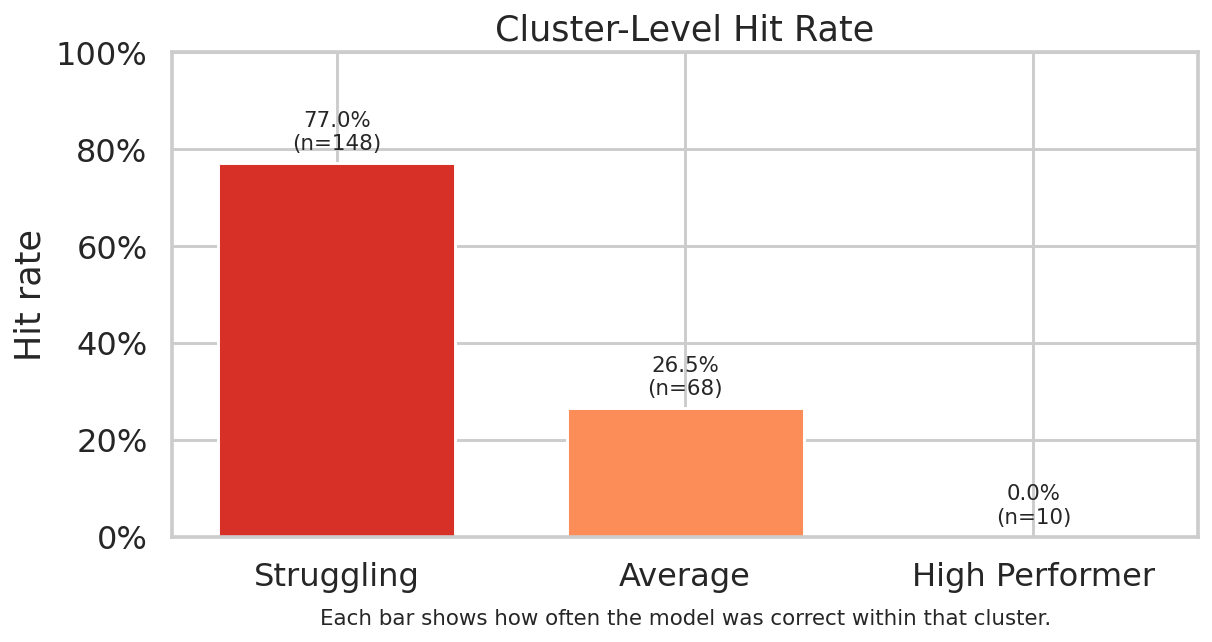

Saved results/learning_curve/exp16_visualizations/exp16_cluster_level_hit_rate.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
palette = {'Struggling': '#d73027', 'Average': '#fc8d59', 'High Performer': '#1a9850'}
bars = ax.bar(
    cluster_summary['Cluster'].astype(str),
    cluster_summary['HitRate'],
    color=[palette[c] for c in cluster_summary['Cluster'].astype(str)],
    width=0.68,
)

ax.set_ylim(0, 1)
ax.set_ylabel('Hit rate')
ax.set_title('Cluster-Level Hit Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

for bar, (_, row) in zip(bars, cluster_summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{row.HitRate:.1%}\n(n={int(row.Validatable)})',
        ha='center',
        va='bottom',
        fontsize=11,
    )

ax.text(0.5, -0.18, 'Each bar shows how often the model was correct within that cluster.', transform=ax.transAxes, ha='center', fontsize=11)
fig.tight_layout()
cluster_path = FIG_DIR / 'exp16_cluster_level_hit_rate.png'
fig.savefig(cluster_path, bbox_inches='tight')
plt.show()
print(f'Saved {cluster_path}')

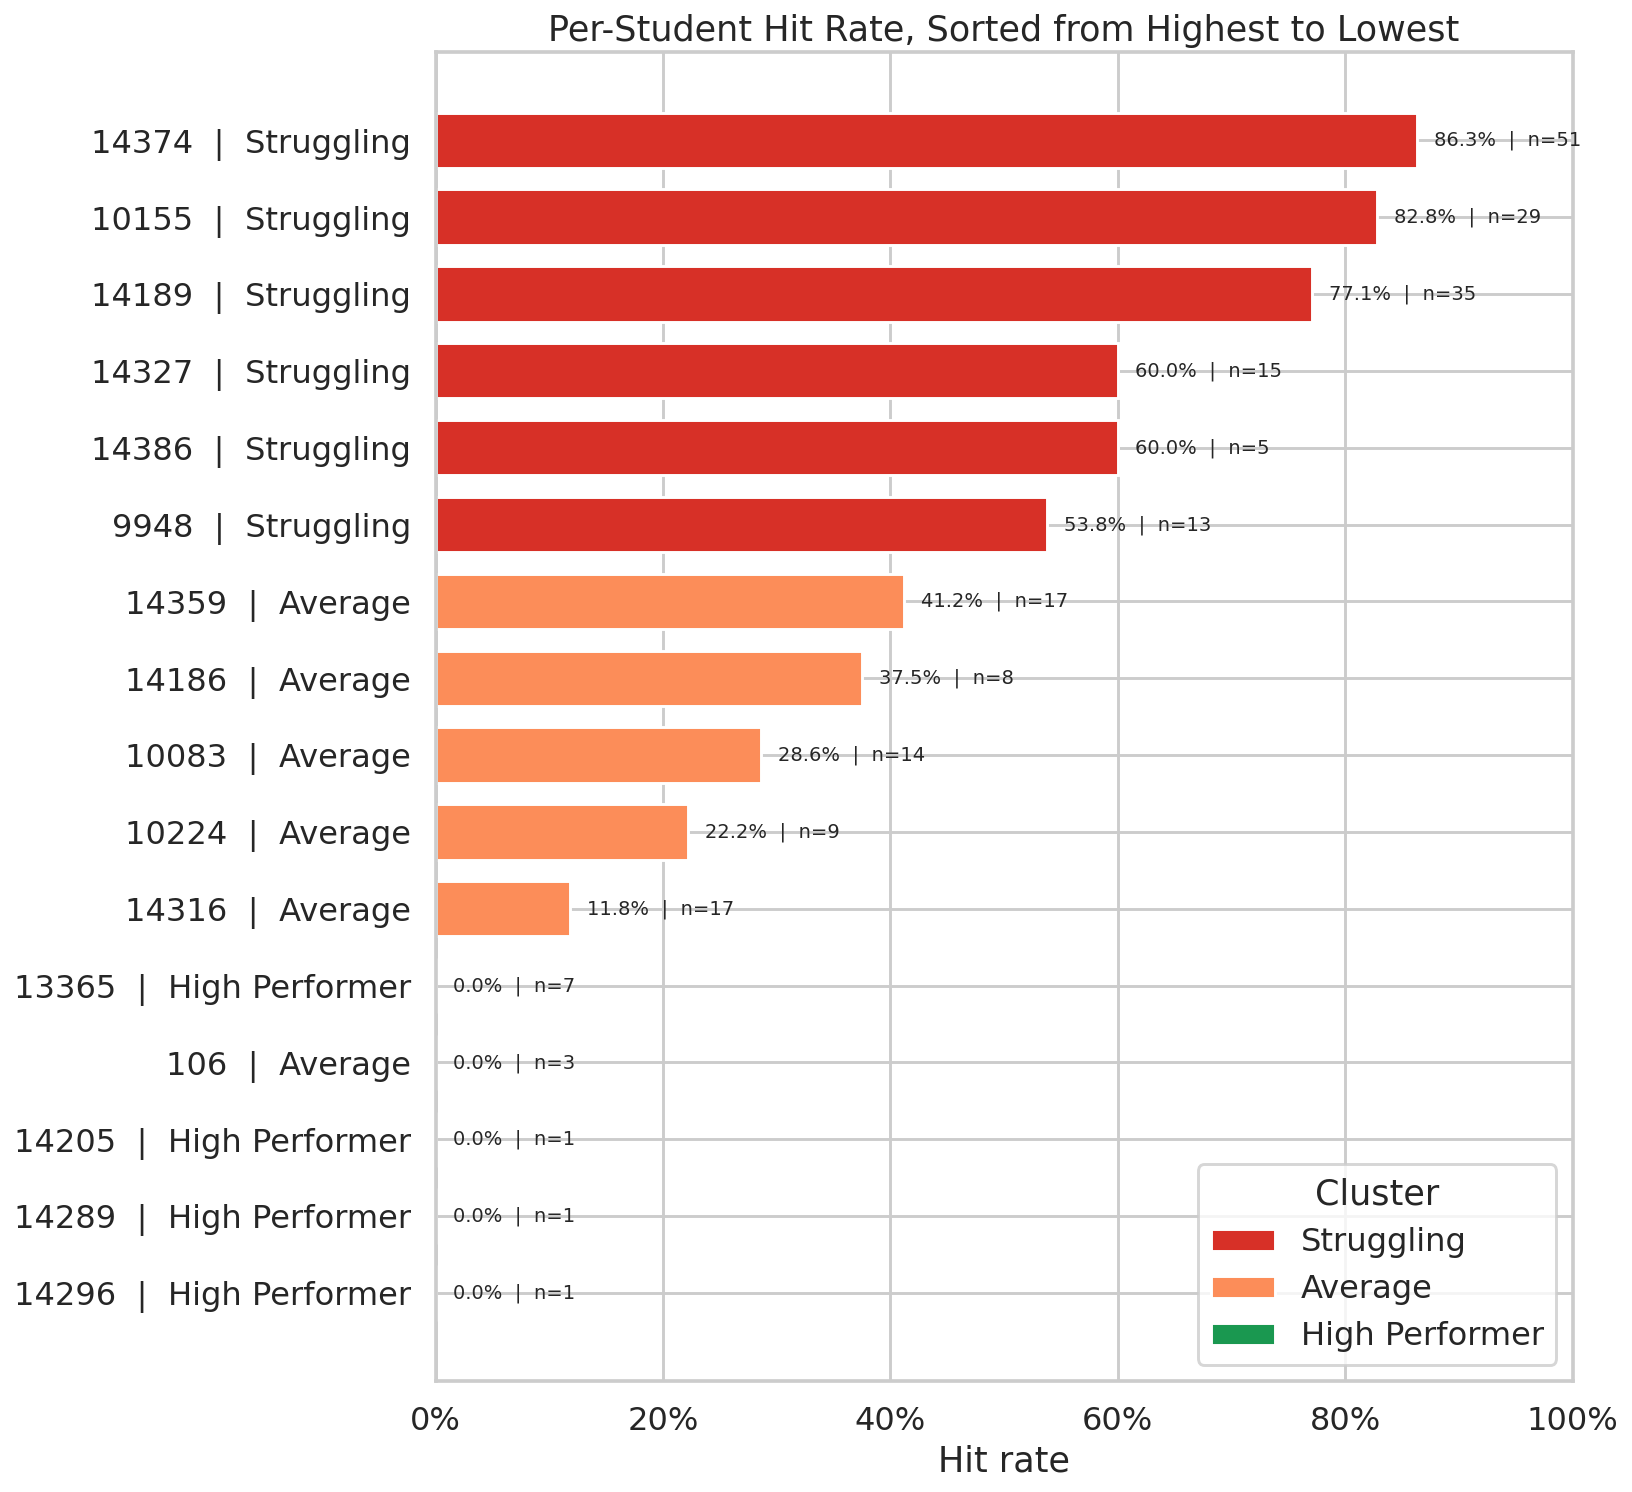

Saved results/learning_curve/exp16_visualizations/exp16_per_student_sorted_hit_rate.png


In [7]:
student_plot = summary_df.sort_values(['HitRate', 'Validatable', 'SubjectID'], ascending=[False, False, True]).copy()
student_plot['Label'] = student_plot.apply(
    lambda row: f"{int(row.SubjectID)}  |  {row.Cluster}", axis=1
)
student_plot['Color'] = student_plot['Cluster'].astype(str).map(palette)

fig, ax = plt.subplots(figsize=(12, 11))
y_pos = range(len(student_plot))
ax.barh(y_pos, student_plot['HitRate'], color=student_plot['Color'], height=0.72)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(student_plot['Label'])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel('Hit rate')
ax.set_title('Per-Student Hit Rate, Sorted from Highest to Lowest')
ax.xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')

for y, (_, row) in enumerate(student_plot.iterrows()):
    ax.text(
        min(row.HitRate + 0.015, 0.985),
        y,
        f'{row.HitRate:.1%}  |  n={int(row.Validatable)}',
        va='center',
        fontsize=10,
    )

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=palette[name], label=name) for name in cluster_order]
ax.legend(handles=legend_handles, title='Cluster', loc='lower right')
fig.tight_layout()
student_path = FIG_DIR / 'exp16_per_student_sorted_hit_rate.png'
fig.savefig(student_path, bbox_inches='tight')
plt.show()
print(f'Saved {student_path}')

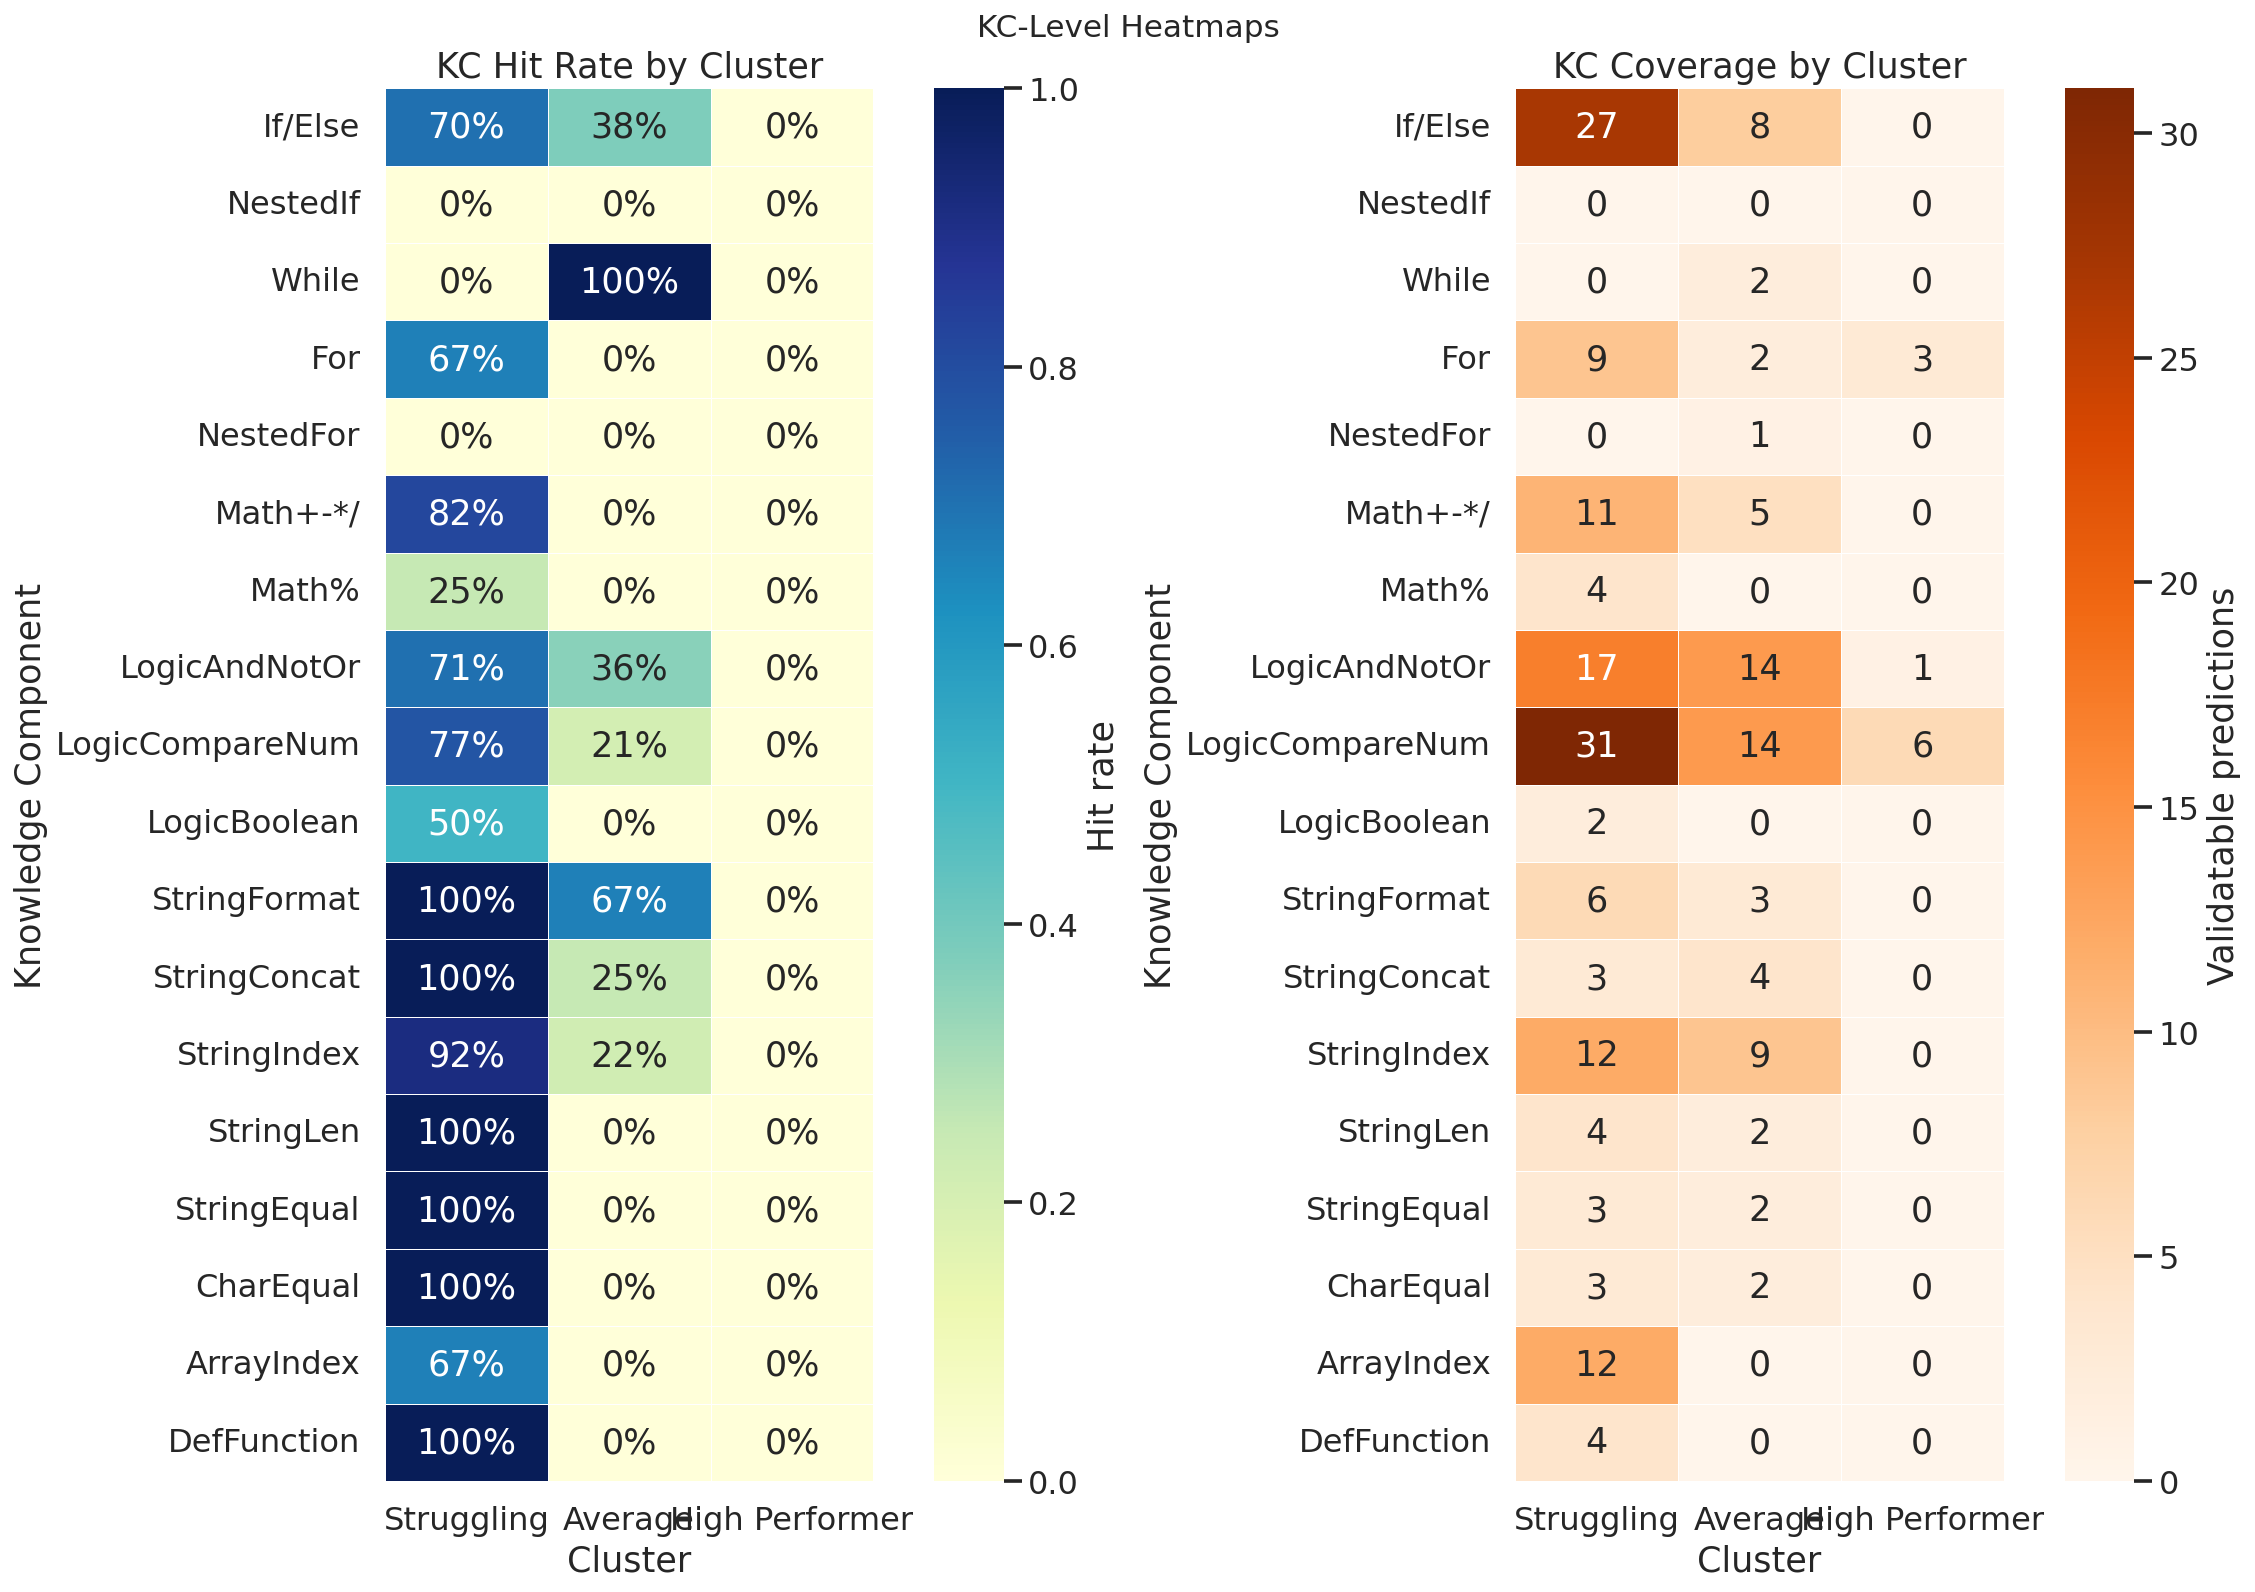

Saved results/learning_curve/exp16_visualizations/exp16_kc_heatmaps_by_cluster.png


In [8]:
kc_cluster = (
    valid_df.groupby(['GapKC', 'Cluster'], observed=True)
    .agg(Validatable=('Prediction', 'size'), TP=('Prediction', lambda s: (s == 'TP').sum()))
    .reset_index()
)
kc_cluster['HitRate'] = kc_cluster['TP'] / kc_cluster['Validatable']

hit_heatmap = (
    kc_cluster.pivot(index='GapKC', columns='Cluster', values='HitRate')
    .reindex(kc_order)
    .reindex(columns=cluster_order)
    .fillna(0)
 )
count_heatmap = (
    kc_cluster.pivot(index='GapKC', columns='Cluster', values='Validatable')
    .reindex(kc_order)
    .reindex(columns=cluster_order)
    .fillna(0)
 )

fig, axes = plt.subplots(1, 2, figsize=(16, 11), constrained_layout=True)
sns.heatmap(
    hit_heatmap,
    annot=True,
    fmt='.0%',
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={'label': 'Hit rate'},
)
axes[0].set_title('KC Hit Rate by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Knowledge Component')

sns.heatmap(
    count_heatmap,
    annot=True,
    fmt='.0f',
    cmap='Oranges',
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={'label': 'Validatable predictions'},
)
axes[1].set_title('KC Coverage by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Knowledge Component')

fig.suptitle('KC-Level Heatmaps', y=1.02, fontsize=16)
heatmap_path = FIG_DIR / 'exp16_kc_heatmaps_by_cluster.png'
fig.savefig(heatmap_path, bbox_inches='tight')
plt.show()
print(f'Saved {heatmap_path}')

## Interpretation

Use the cluster bar chart for the main group comparison, the sorted student chart to see spread across individual learners, and the KC heatmaps to check which skills are easier or harder for each cluster.

All figures are saved in `results/learning_curve/exp16_visualizations/`.